# 02 — Feature Engineering & Target Construction

Build the forward realized-volatility targets and the full feature matrix. The critical constraint: **every feature at date $t$ uses information available at the close of $t$ only.**

Target definition (annualized):

$$RV^{fwd}_{t,h} = \sqrt{\frac{252}{h} \sum_{i=t+1}^{t+h} r_i^2}$$

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 100,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")


In [2]:
from src.data import build_market_dataset
from src.features import build_features, feature_columns

market = build_market_dataset()
df = build_features(market)
features = feature_columns(df)
print(f"{len(df):,} rows x {len(features)} features, {df.index[0].date()} to {df.index[-1].date()}")
print("\nFeatures:")
for i in range(0, len(features), 4):
    print("   " + ", ".join(features[i:i+4]))

3,957 rows x 35 features, 2010-10-18 to 2026-07-14

Features:
   log_return_1d, return_5d, return_10d, return_21d
   return_63d, rv_5d, rv_10d, rv_21d
   rv_63d, ret_mean_21d, ret_std_21d, ret_skew_63d
   dist_ma_21d, dist_ma_63d, dist_ma_200d, parkinson_10d
   parkinson_21d, garman_klass_21d, vix, vix_change_1d
   vix_change_5d, vix_pct_change_1d, vix_mean_21d, vix_std_21d
   vix_rv_spread, drawdown, max_drawdown_63d, neg_return_frac_21d
   downside_vol_21d, volume_change_1d, relative_volume_21d, volume_trend_5_21
   yield_10y, yield_10y_change_21d, term_spread


## Verifying target alignment (no look-ahead)

Manual check: the target at date $t$ must equal the realized vol computed from the *next* 5 daily returns, not including $r_t$.

In [3]:
from src.features import log_returns

r = log_returns(market["adj_close"])
t = df.index[1000]
pos = market.index.get_loc(t)
future_returns = r.iloc[pos + 1 : pos + 6]          # r_{t+1} .. r_{t+5}
manual = np.sqrt(252 / 5 * (future_returns ** 2).sum())
print(f"date t:                 {t.date()}")
print(f"future window:          {future_returns.index[0].date()} .. {future_returns.index[-1].date()}")
print(f"manual forward RV:      {manual:.6f}")
print(f"pipeline rv_5d_forward: {df.loc[t, 'rv_5d_forward']:.6f}")
assert np.isclose(manual, df.loc[t, "rv_5d_forward"])
print("alignment verified: target uses only returns AFTER date t")

date t:                 2014-10-08
future window:          2014-10-09 .. 2014-10-15
manual forward RV:      0.207696
pipeline rv_5d_forward: 0.207696
alignment verified: target uses only returns AFTER date t


## Which features correlate with future volatility?

In [4]:
corr = df[features].corrwith(df["rv_5d_forward"]).sort_values(key=abs, ascending=False)
corr.head(12).to_frame("correlation with rv_5d_forward")

,correlation with rv_5d_forward
vix,0.7145
rv_5d,0.6576
parkinson_10d,0.6534
rv_10d,0.6489
downside_vol_21d,0.6315
drawdown,-0.6159
garman_klass_21d,0.5907
rv_21d,0.5891
parkinson_21d,0.5883
ret_std_21d,0.5837


## Volatility regimes

Terciles of trailing 21-day realized volatility define low / medium / high regimes. Breakpoints are estimated on the training period only when used for evaluation (see `src/evaluation.py`); here we preview the behaviour of future volatility across regimes.

In [5]:
from src.evaluation import assign_regimes, chronological_split

split = chronological_split(len(df))
train = df.iloc[:split.train_end]
regimes = assign_regimes(df["rv_21d"], train["rv_21d"])
df.groupby(regimes)["rv_5d_forward"].describe()[["count", "mean", "50%", "std", "max"]]

,count,mean,50%,std,max
regime,,,,,
high,1472.0000,0.1917,0.1650,0.1342,1.3421
low,1078.0000,0.0954,0.0811,0.0559,0.4591
medium,1407.0000,0.1103,0.1020,0.0550,0.4990


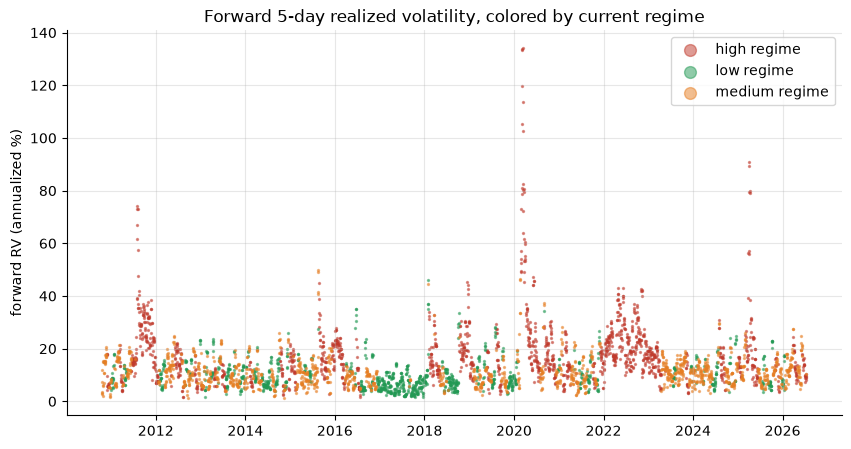

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"low": "#229954", "medium": "#e67e22", "high": "#c0392b"}
for name, group in df.groupby(regimes):
    ax.scatter(group.index, group["rv_5d_forward"] * 100, s=2, alpha=0.5,
               color=colors[name], label=f"{name} regime")
ax.set_title("Forward 5-day realized volatility, colored by current regime")
ax.set_ylabel("forward RV (annualized %)")
ax.legend(markerscale=6);